In [ ]:
!pip install nltk scikit-learn seaborn

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
import re

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/smart_complaints_dataset_4000.csv")

df.head()

,complaint_id,complaint_text,category,priority,department,location,date_submitted,status
0,1,Noise disturbance at night,Police/Safety,Medium,Police/Safety,Kolkata,2025-03-25,In Progress
1,2,Overflowing dustbins in the area,Sanitation,High,Sanitation,Chennai,2025-07-04,Pending
2,3,Shortage of medicines in health center,Health,Medium,Health,Ranchi,2024-08-14,Resolved
3,4,Vaccination not available in local clinic,Health,Medium,Health,Mumbai,2024-06-09,In Progress
4,5,UPI payment fraud reported,IT Fraud,Medium,IT Fraud,Hyderabad,2025-02-19,Resolved


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   complaint_id    4000 non-null   int64 
 1   complaint_text  4000 non-null   object
 2   category        4000 non-null   object
 3   priority        4000 non-null   object
 4   department      4000 non-null   object
 5   location        4000 non-null   object
 6   date_submitted  4000 non-null   object
 7   status          4000 non-null   object
dtypes: int64(1), object(7)
memory usage: 250.1+ KB


In [ ]:
df.describe()

,complaint_id
count,4000.000000
mean,2000.500000
std,1154.844867
min,1.000000
25%,1000.750000
50%,2000.500000
75%,3000.250000
max,4000.000000


In [ ]:
df.isnull().sum()

,0
complaint_id,0
complaint_text,0
category,0
priority,0
department,0
location,0
date_submitted,0
status,0


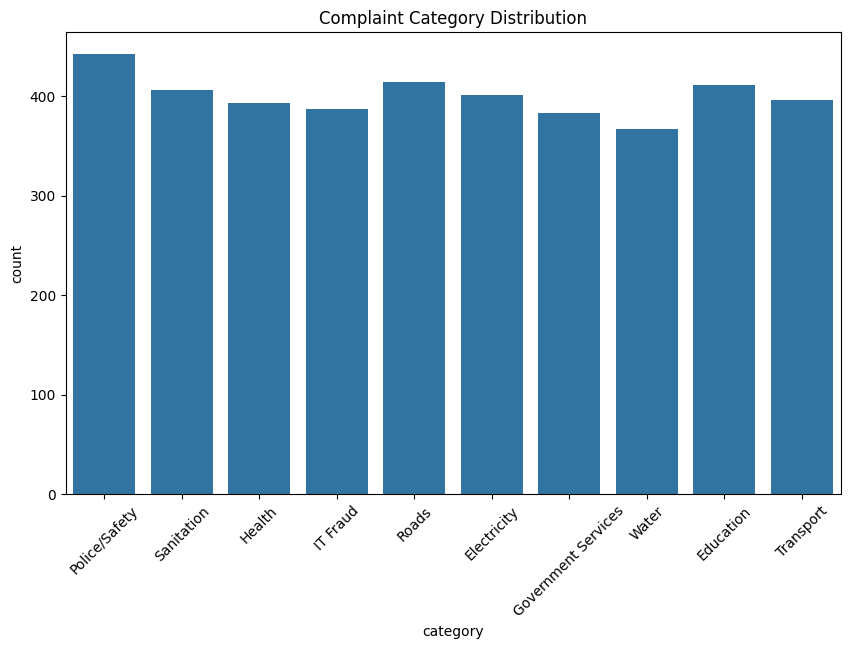

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="category")

plt.xticks(rotation=45)

plt.title("Complaint Category Distribution")

plt.show()

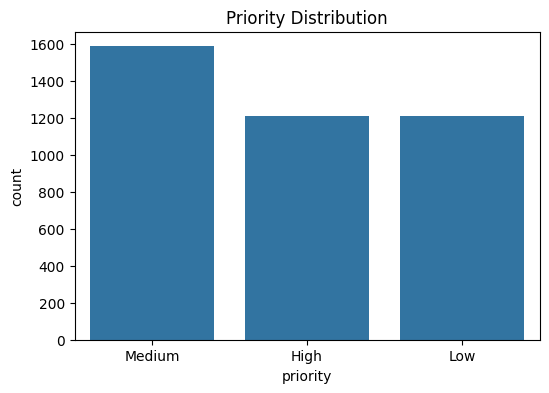

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="priority")

plt.title("Priority Distribution")

plt.show()

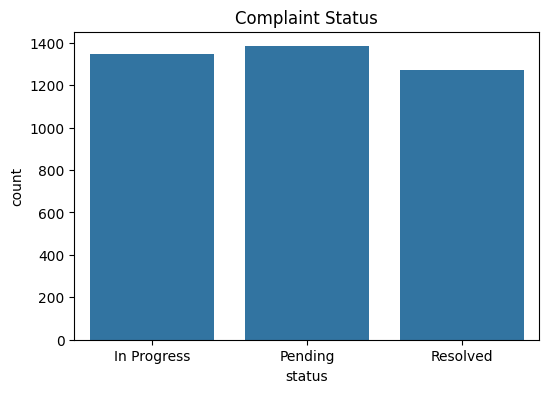

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=df, x="status")

plt.title("Complaint Status")

plt.show()

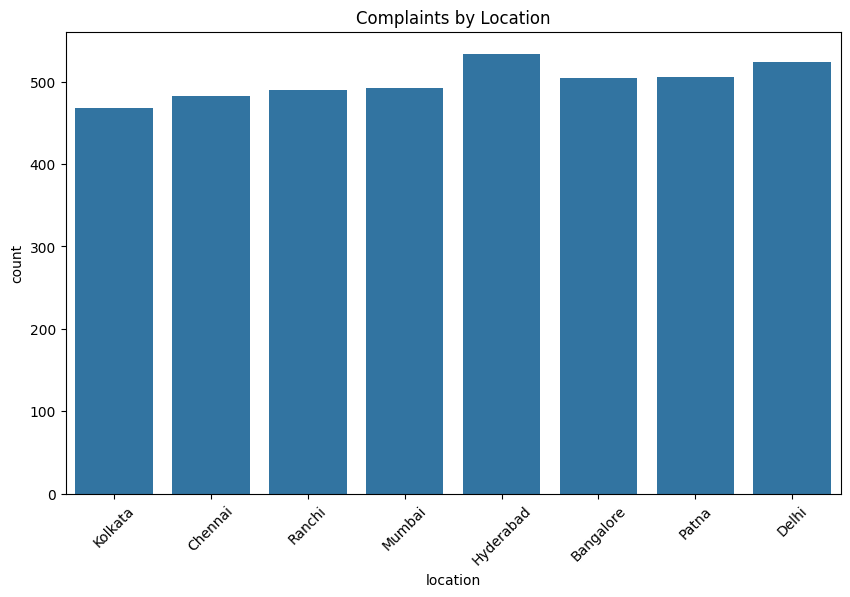

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(data=df, x="location")

plt.xticks(rotation=45)

plt.title("Complaints by Location")

plt.show()

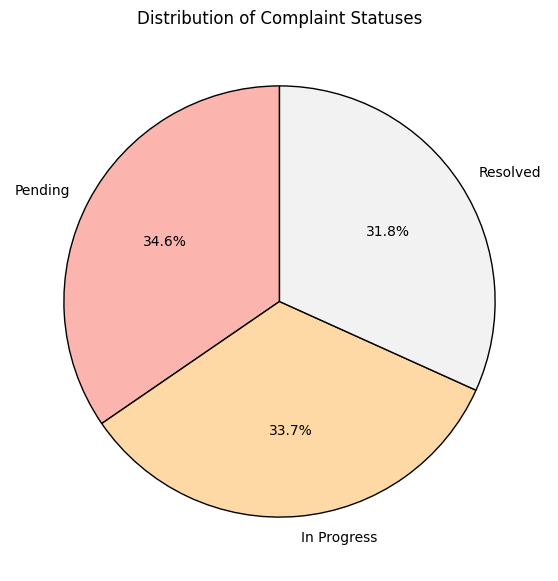

In [ ]:
plt.figure(figsize=(7, 7))
df['status'].value_counts().plot.pie(autopct='%1.1f%%', startangle=90, cmap='Pastel1', wedgeprops={'edgecolor': 'black'})
plt.title('Distribution of Complaint Statuses')
plt.ylabel('')
plt.show()

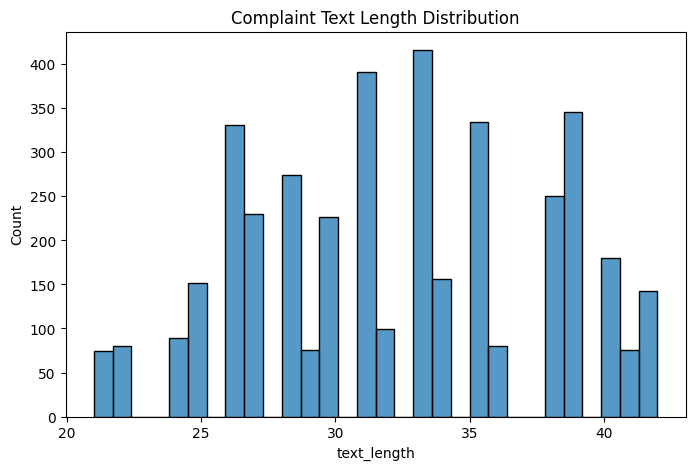

In [ ]:
df["text_length"] = df["complaint_text"].apply(len)

plt.figure(figsize=(8,5))

sns.histplot(df["text_length"], bins=30)

plt.title("Complaint Text Length Distribution")

plt.show()

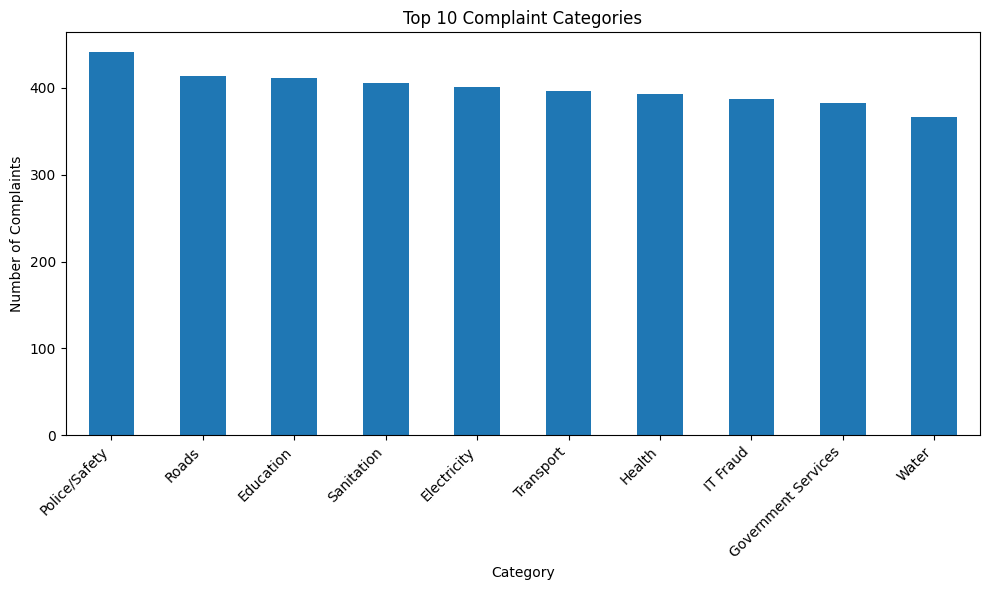

In [ ]:
plt.figure(figsize=(10, 6))
df['category'].value_counts().head(10).plot(kind='bar')
plt.title('Top 10 Complaint Categories')
plt.xlabel('Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Convert 'date_submitted' to datetime objects
df['date_submitted'] = pd.to_datetime(df['date_submitted'])



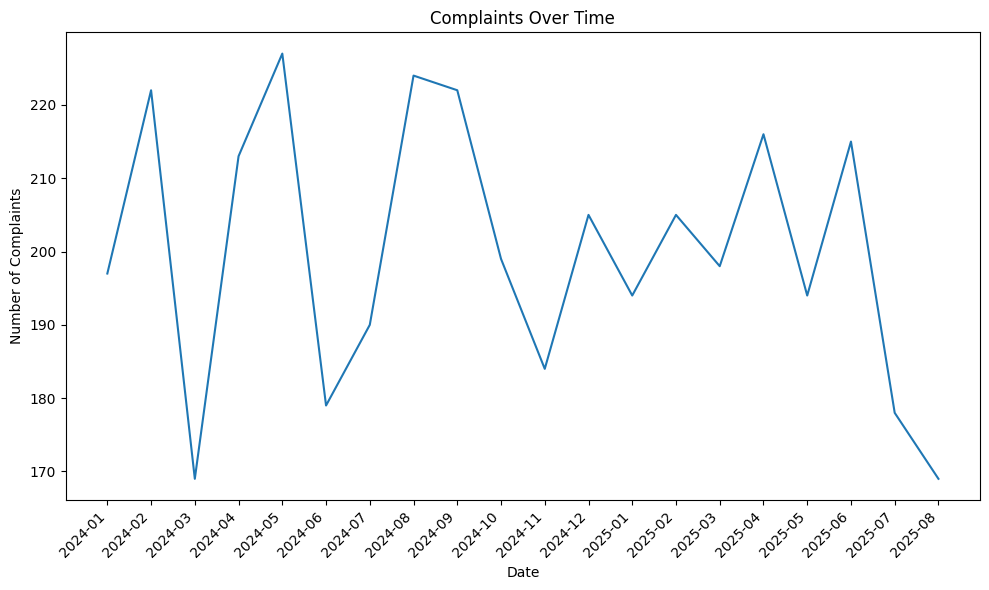

In [ ]:
# Group complaints by date and count them
complaints_over_time = df.groupby(df['date_submitted'].dt.to_period('M')).size().reset_index(name='count')
complaints_over_time['date_submitted'] = complaints_over_time['date_submitted'].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(data=complaints_over_time, x='date_submitted', y='count')
plt.title('Complaints Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



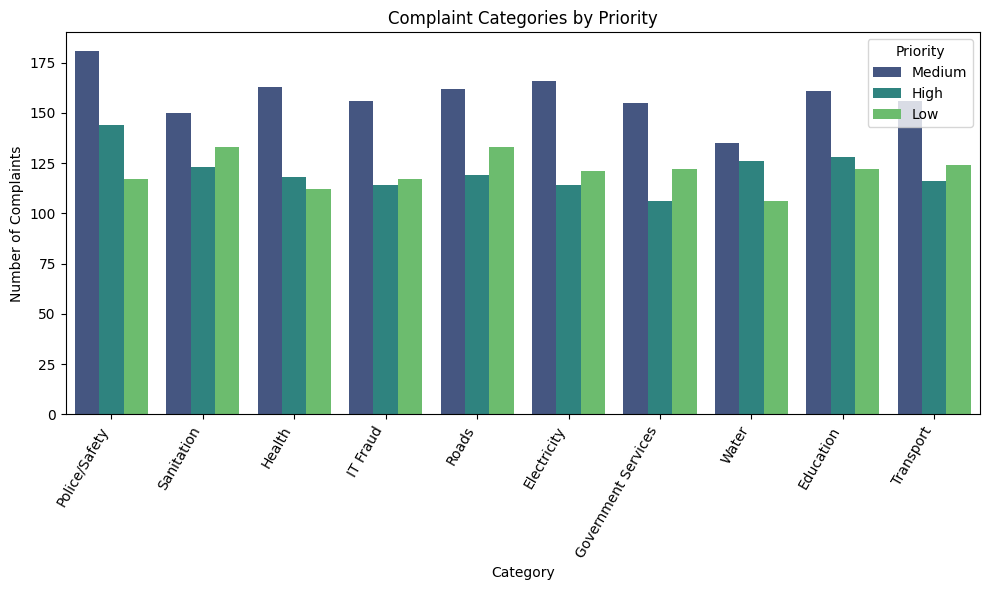

In [ ]:
# Relationship between category and priority
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='category', hue='priority', palette='viridis')
plt.title('Complaint Categories by Priority')
plt.xlabel('Category')
plt.ylabel('Number of Complaints')
plt.xticks(rotation=60, ha='right')
plt.legend(title='Priority')
plt.tight_layout()
plt.show()

In [ ]:
stop_words = set(stopwords.words("english"))

def clean_text(text):

    text = text.lower()

    text = re.sub(r'[^a-zA-Z ]','',text)

    words = text.split()

    words = [w for w in words if w not in stop_words]

    return " ".join(words)

df["clean_text"] = df["complaint_text"].apply(clean_text)

df.head()

,complaint_id,complaint_text,category,priority,department,location,date_submitted,status,text_length,clean_text
0,1,Noise disturbance at night,Police/Safety,Medium,Police/Safety,Kolkata,2025-03-25,In Progress,26,noise disturbance night
1,2,Overflowing dustbins in the area,Sanitation,High,Sanitation,Chennai,2025-07-04,Pending,32,overflowing dustbins area
2,3,Shortage of medicines in health center,Health,Medium,Health,Ranchi,2024-08-14,Resolved,38,shortage medicines health center
3,4,Vaccination not available in local clinic,Health,Medium,Health,Mumbai,2024-06-09,In Progress,41,vaccination available local clinic
4,5,UPI payment fraud reported,IT Fraud,Medium,IT Fraud,Hyderabad,2025-02-19,Resolved,26,upi payment fraud reported


In [ ]:
vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(df["clean_text"])

In [ ]:
print(X)

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 16027 stored elements and shape (4000, 159)>
  Coords	Values
  (0, 102)	0.5773502691896257
  (0, 46)	0.5773502691896257
  (0, 101)	0.5773502691896257
  (1, 107)	0.6224609683127299
  (1, 52)	0.6224609683127299
  (1, 8)	0.4744309073557047
  (2, 136)	0.5
  (2, 94)	0.5
  (2, 71)	0.5
  (2, 25)	0.5
  (3, 153)	0.5354510309945802
  (3, 12)	0.46576291510582335
  (3, 88)	0.4578747576857754
  (3, 29)	0.5354510309945802
  (4, 152)	0.5808662737385231
  (4, 108)	0.501607678602888
  (4, 60)	0.497824663275493
  (4, 125)	0.40392414316847514
  (5, 76)	0.5
  (5, 3)	0.5
  (5, 69)	0.5
  (5, 99)	0.5
  (6, 107)	0.6224609683127299
  (6, 52)	0.6224609683127299
  (6, 8)	0.4744309073557047
  :	:
  (3993, 24)	0.41595302284488855
  (3993, 62)	0.4840220648188891
  (3993, 117)	0.4840220648188891
  (3993, 1)	0.4840220648188891
  (3994, 115)	0.5030650135734064
  (3994, 72)	0.5697406127297158
  (3994, 75)	0.6498624672380738
  (3995, 102)	0.5773502691896257
 

In [ ]:
y_category = df["category"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y_category,test_size=0.2,random_state=42
)

model_category = LogisticRegression(max_iter=200)

model_category.fit(X_train,y_train)

pred_cat = model_category.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_cat))

print(classification_report(y_test,pred_cat))

Accuracy: 1.0
                     precision    recall  f1-score   support

          Education       1.00      1.00      1.00        74
        Electricity       1.00      1.00      1.00        74
Government Services       1.00      1.00      1.00        73
             Health       1.00      1.00      1.00        79
           IT Fraud       1.00      1.00      1.00        90
      Police/Safety       1.00      1.00      1.00        95
              Roads       1.00      1.00      1.00        73
         Sanitation       1.00      1.00      1.00        92
          Transport       1.00      1.00      1.00        72
              Water       1.00      1.00      1.00        78

           accuracy                           1.00       800
          macro avg       1.00      1.00      1.00       800
       weighted avg       1.00      1.00      1.00       800



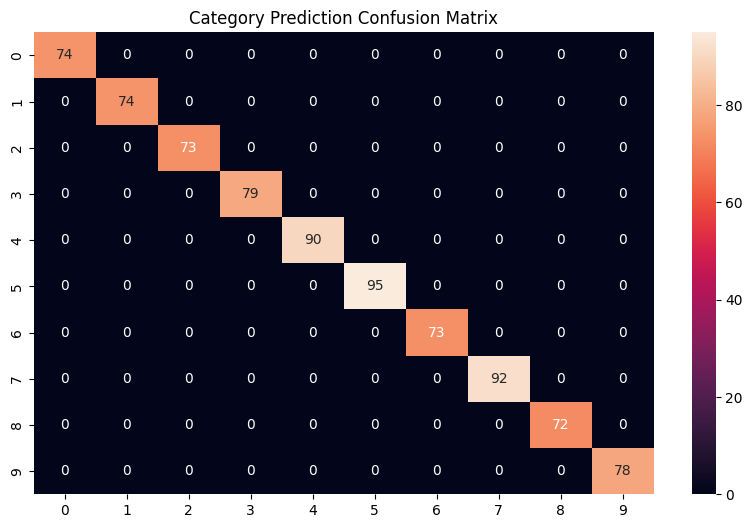

In [ ]:
cm = confusion_matrix(y_test,pred_cat)

plt.figure(figsize=(10,6))

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Category Prediction Confusion Matrix")

plt.show()

In [ ]:
y_priority = df["priority"]

X_train,X_test,y_train,y_test = train_test_split(
    X,y_priority,test_size=0.2,random_state=42
)

model_priority = LogisticRegression(max_iter=200)

model_priority.fit(X_train,y_train)

pred_pri = model_priority.predict(X_test)

print("Accuracy:",accuracy_score(y_test,pred_pri))

print(classification_report(y_test,pred_pri))

Accuracy: 0.37625
              precision    recall  f1-score   support

        High       0.28      0.18      0.22       232
         Low       0.32      0.15      0.20       243
      Medium       0.41      0.69      0.52       325

    accuracy                           0.38       800
   macro avg       0.34      0.34      0.31       800
weighted avg       0.35      0.38      0.34       800



In [ ]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=10)

clusters = kmeans.fit_predict(X)

df["cluster"] = clusters

df.head()

,complaint_id,complaint_text,category,priority,department,location,date_submitted,status,text_length,clean_text,cluster
0,1,Noise disturbance at night,Police/Safety,Medium,Police/Safety,Kolkata,2025-03-25,In Progress,26,noise disturbance night,1
1,2,Overflowing dustbins in the area,Sanitation,High,Sanitation,Chennai,2025-07-04,Pending,32,overflowing dustbins area,0
2,3,Shortage of medicines in health center,Health,Medium,Health,Ranchi,2024-08-14,Resolved,38,shortage medicines health center,1
3,4,Vaccination not available in local clinic,Health,Medium,Health,Mumbai,2024-06-09,In Progress,41,vaccination available local clinic,7
4,5,UPI payment fraud reported,IT Fraud,Medium,IT Fraud,Hyderabad,2025-02-19,Resolved,26,upi payment fraud reported,3


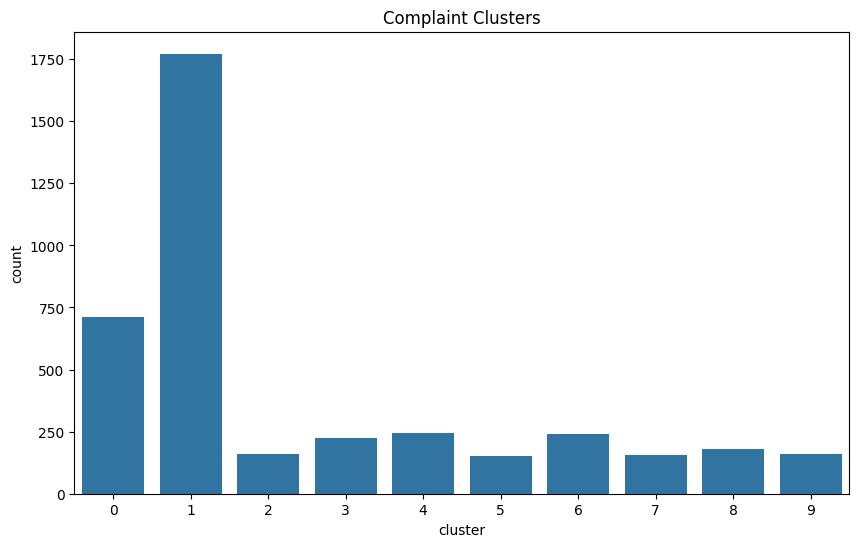

In [ ]:
plt.figure(figsize=(10,6))

sns.countplot(data=df,x="cluster")

plt.title("Complaint Clusters")

plt.show()

In [ ]:
import pickle

pickle.dump(model_category,open("category_model.pkl","wb"))

pickle.dump(model_priority,open("priority_model.pkl","wb"))

pickle.dump(vectorizer,open("vectorizer.pkl","wb"))

In [ ]:
files.download("category_model.pkl")
files.download("priority_model.pkl")
files.download("vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
def predict_complaint(text):

    clean = clean_text(text)

    vec = vectorizer.transform([clean])

    category = model_category.predict(vec)[0]

    priority = model_priority.predict(vec)[0]

    print("Category:",category)
    print("Priority:",priority)

predict_complaint("There is a huge pothole on the road causing accidents")

Category: Roads
Priority: Medium
